# Dukascopy Data Quality Analysis

This notebook provides a comprehensive analysis of the downloaded Dukascopy tick data quality.

## Analysis Includes:
1. **Basic Statistics** - Record counts, date ranges, file metadata
2. **Data Completeness** - Missing data, gaps, coverage
3. **Price Validation** - Bid/ask prices, spreads, outliers
4. **Temporal Analysis** - Time gaps, tick frequency, trading hours
5. **Statistical Analysis** - Distributions, correlations, anomalies
6. **Visualizations** - Charts and graphs for data quality assessment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import pyarrow.parquet as pq
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration - Find project root by looking for data directory
# Works whether running from scripts/ or project root
current = Path.cwd()
if (current / "data").exists():
    PROJECT_ROOT = current
elif (current.parent / "data").exists():
    PROJECT_ROOT = current.parent
else:
    # Fallback: assume we're in scripts/ and go up one level
    PROJECT_ROOT = current.parent

PARQUET_FILE = PROJECT_ROOT / "data" / "dukascopy" / "EURUSD" / "2024.parquet"
SYMBOL = "EURUSD"

print(f"Current directory: {current}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Loading data from: {PARQUET_FILE}")
print(f"File exists: {PARQUET_FILE.exists()}")
print(f"Symbol: {SYMBOL}")

Current directory: c:\Users\maxno\Desktop\Projet\1.1\scripts
Project root: c:\Users\maxno\Desktop\Projet\1.1
Loading data from: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2024.parquet
File exists: True
Symbol: EURUSD


## 1. Load Data and Basic Information

In [2]:
# Load parquet file
df = pd.read_parquet(PARQUET_FILE)

# Ensure timestamp is datetime
if not pd.api.types.is_datetime64_any_dtype(df['timestamp']):
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

# Sort by timestamp
df = df.sort_values('timestamp').reset_index(drop=True)

# Read metadata
parquet_file = pq.ParquetFile(PARQUET_FILE)
metadata = parquet_file.schema_arrow.metadata

print(f"\n{'='*80}")
print("BASIC INFORMATION")
print(f"{'='*80}")
print(f"Total Records: {len(df):,}")
print(f"Date Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Duration: {(df['timestamp'].max() - df['timestamp'].min()).days} days")
print(f"\nFile Size: {PARQUET_FILE.stat().st_size / (1024*1024):.2f} MB")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nFirst few records:")
print(df.head(10))
print(f"\nLast few records:")
print(df.tail(10))


BASIC INFORMATION
Total Records: 20,687,149
Date Range: 2024-01-01 22:00:12.108000+00:00 to 2024-12-31 21:59:58.249000+00:00
Duration: 364 days

File Size: 266.97 MB

Columns: ['timestamp', 'bid', 'ask', 'symbol']

Data Types:
timestamp    datetime64[ns, UTC]
bid                      float64
ask                      float64
symbol                  category
dtype: object

First few records:
                         timestamp      bid      ask  symbol
0 2024-01-01 22:00:12.108000+00:00  1.10427  1.10481  EURUSD
1 2024-01-01 22:00:14.513000+00:00  1.10425  1.10480  EURUSD
2 2024-01-01 22:00:18.925000+00:00  1.10425  1.10476  EURUSD
3 2024-01-01 22:00:25.498000+00:00  1.10425  1.10480  EURUSD
4 2024-01-01 22:00:36.129000+00:00  1.10429  1.10480  EURUSD
5 2024-01-01 22:00:44.956000+00:00  1.10425  1.10480  EURUSD
6 2024-01-01 22:00:54.534000+00:00  1.10429  1.10480  EURUSD
7 2024-01-01 22:01:04.364000+00:00  1.10429  1.10477  EURUSD
8 2024-01-01 22:01:08.324000+00:00  1.10429  1.10478  EUR

## 2. Data Completeness Analysis

In [3]:
# Check for null values
null_counts = df.isnull().sum()
print(f"\n{'='*80}")
print("NULL VALUES CHECK")
print(f"{'='*80}")
for col, count in null_counts.items():
    if count > 0:
        print(f"⚠️  {col}: {count:,} null values ({count/len(df)*100:.2f}%)")
    else:
        print(f"✓ {col}: No null values")

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicate_count:,} ({duplicate_count/len(df)*100:.2f}%)")

# Check date coverage
date_range = pd.date_range(
    start=df['timestamp'].min().date(),
    end=df['timestamp'].max().date(),
    freq='D'
)
actual_dates = df['timestamp'].dt.date.unique()
missing_dates = set(date_range.date) - set(actual_dates)

print(f"\nDate Coverage:")
print(f"  Expected days: {len(date_range)}")
print(f"  Actual days with data: {len(actual_dates)}")
print(f"  Missing days: {len(missing_dates)}")
if missing_dates:
    print(f"  Missing dates: {sorted(missing_dates)[:10]}..." if len(missing_dates) > 10 else f"  Missing dates: {sorted(missing_dates)}")


NULL VALUES CHECK
✓ timestamp: No null values
✓ bid: No null values
✓ ask: No null values
✓ symbol: No null values

Duplicate Records: 0 (0.00%)

Date Coverage:
  Expected days: 366
  Actual days with data: 314
  Missing days: 52
  Missing dates: [datetime.date(2024, 1, 6), datetime.date(2024, 1, 13), datetime.date(2024, 1, 20), datetime.date(2024, 1, 27), datetime.date(2024, 2, 3), datetime.date(2024, 2, 10), datetime.date(2024, 2, 17), datetime.date(2024, 2, 24), datetime.date(2024, 3, 2), datetime.date(2024, 3, 9)]...


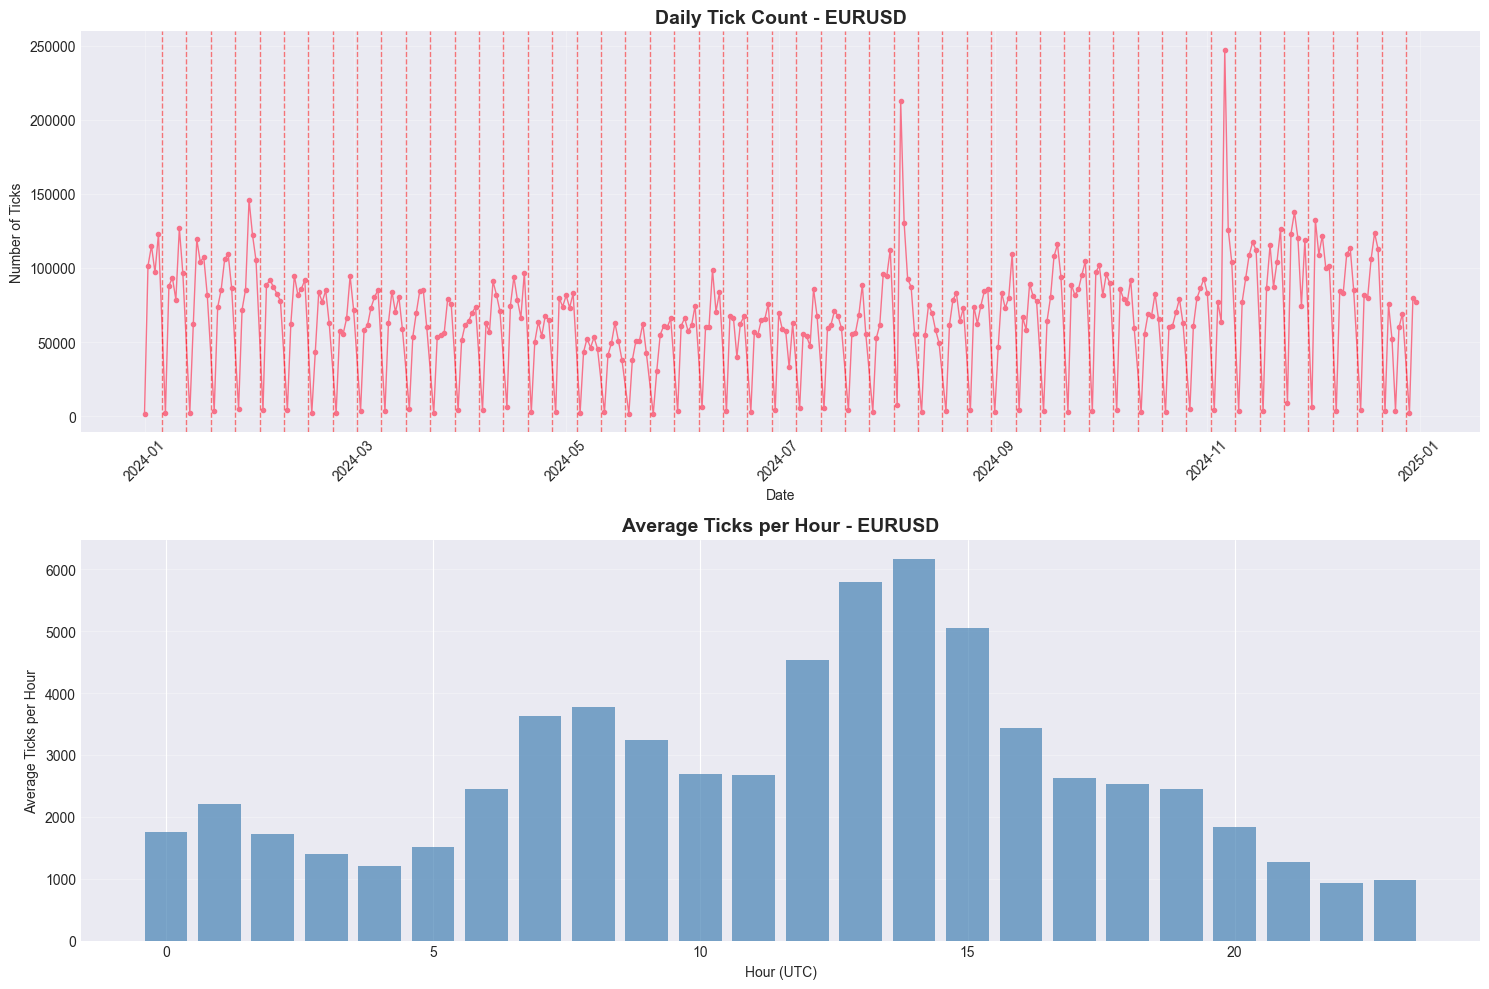


Hourly Statistics:
  Peak hour: 14 UTC (6168 ticks/hour)
  Lowest hour: 22 UTC (934 ticks/hour)
  Average: 2745 ticks/hour


In [4]:
# Visualize date coverage
df['date'] = df['timestamp'].dt.date
daily_counts = df.groupby('date').size()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Daily tick counts
axes[0].plot(daily_counts.index, daily_counts.values, marker='o', markersize=3, linewidth=1)
axes[0].set_title(f'Daily Tick Count - {SYMBOL}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Ticks')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Missing dates highlighted
if missing_dates:
    for missing_date in missing_dates:
        axes[0].axvline(x=missing_date, color='red', linestyle='--', alpha=0.5, linewidth=1)

# Hourly distribution (average across all days)
df['hour'] = df['timestamp'].dt.hour
hourly_avg = df.groupby('hour').size() / len(df['date'].unique())

axes[1].bar(hourly_avg.index, hourly_avg.values, color='steelblue', alpha=0.7)
axes[1].set_title(f'Average Ticks per Hour - {SYMBOL}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_ylabel('Average Ticks per Hour')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nHourly Statistics:")
print(f"  Peak hour: {hourly_avg.idxmax()} UTC ({hourly_avg.max():.0f} ticks/hour)")
print(f"  Lowest hour: {hourly_avg.idxmin()} UTC ({hourly_avg.min():.0f} ticks/hour)")
print(f"  Average: {hourly_avg.mean():.0f} ticks/hour")

## 3. Price Data Validation

In [5]:
# Calculate spread
df['spread'] = df['ask'] - df['bid']
df['spread_pips'] = df['spread'] * 10000  # For EURUSD (5 decimal places)
df['mid_price'] = (df['bid'] + df['ask']) / 2

print(f"\n{'='*80}")
print("PRICE STATISTICS")
print(f"{'='*80}")
print(f"\nBid Price:")
print(df['bid'].describe())
print(f"\nAsk Price:")
print(df['ask'].describe())
print(f"\nSpread:")
print(df['spread'].describe())
print(f"\nSpread (Pips):")
print(df['spread_pips'].describe())

# Check for issues
negative_spreads = (df['spread'] < 0).sum()
zero_spreads = (df['spread'] == 0).sum()
very_large_spreads = (df['spread_pips'] > 10).sum()  # > 10 pips is unusual for EURUSD

print(f"\n{'='*80}")
print("PRICE VALIDATION CHECKS")
print(f"{'='*80}")
if negative_spreads > 0:
    print(f"⚠️  Negative spreads: {negative_spreads:,} ({negative_spreads/len(df)*100:.4f}%)")
else:
    print(f"✓ No negative spreads")

if zero_spreads > 0:
    print(f"⚠️  Zero spreads: {zero_spreads:,} ({zero_spreads/len(df)*100:.2f}%)")
else:
    print(f"✓ No zero spreads")

if very_large_spreads > 0:
    print(f"⚠️  Very large spreads (>10 pips): {very_large_spreads:,} ({very_large_spreads/len(df)*100:.2f}%)")
else:
    print(f"✓ No unusually large spreads")

# Check for price outliers (using IQR method)
Q1_bid = df['bid'].quantile(0.25)
Q3_bid = df['bid'].quantile(0.75)
IQR_bid = Q3_bid - Q1_bid
outlier_bid = ((df['bid'] < (Q1_bid - 3 * IQR_bid)) | (df['bid'] > (Q3_bid + 3 * IQR_bid))).sum()

Q1_ask = df['ask'].quantile(0.25)
Q3_ask = df['ask'].quantile(0.75)
IQR_ask = Q3_ask - Q1_ask
outlier_ask = ((df['ask'] < (Q1_ask - 3 * IQR_ask)) | (df['ask'] > (Q3_ask + 3 * IQR_ask))).sum()

print(f"\nPrice Outliers (3*IQR method):")
print(f"  Bid outliers: {outlier_bid:,} ({outlier_bid/len(df)*100:.2f}%)")
print(f"  Ask outliers: {outlier_ask:,} ({outlier_ask/len(df)*100:.2f}%)")


PRICE STATISTICS

Bid Price:
count    2.068715e+07
mean     1.081391e+00
std      1.865368e-02
min      1.033250e+00
25%      1.071760e+00
50%      1.083350e+00
75%      1.092530e+00
max      1.121400e+00
Name: bid, dtype: float64

Ask Price:
count    2.068715e+07
mean     1.081417e+00
std      1.865287e-02
min      1.033270e+00
25%      1.071780e+00
50%      1.083380e+00
75%      1.092560e+00
max      1.121420e+00
Name: ask, dtype: float64

Spread:
count    2.068715e+07
mean     2.598304e-05
std      2.721439e-05
min      0.000000e+00
25%      2.000000e-05
50%      2.000000e-05
75%      3.000000e-05
max      2.850000e-03
Name: spread, dtype: float64

Spread (Pips):
count    2.068715e+07
mean     2.598304e-01
std      2.721439e-01
min      0.000000e+00
25%      2.000000e-01
50%      2.000000e-01
75%      3.000000e-01
max      2.850000e+01
Name: spread_pips, dtype: float64

PRICE VALIDATION CHECKS
✓ No negative spreads
⚠️  Zero spreads: 1,589 (0.01%)
⚠️  Very large spreads (>10 pips): 

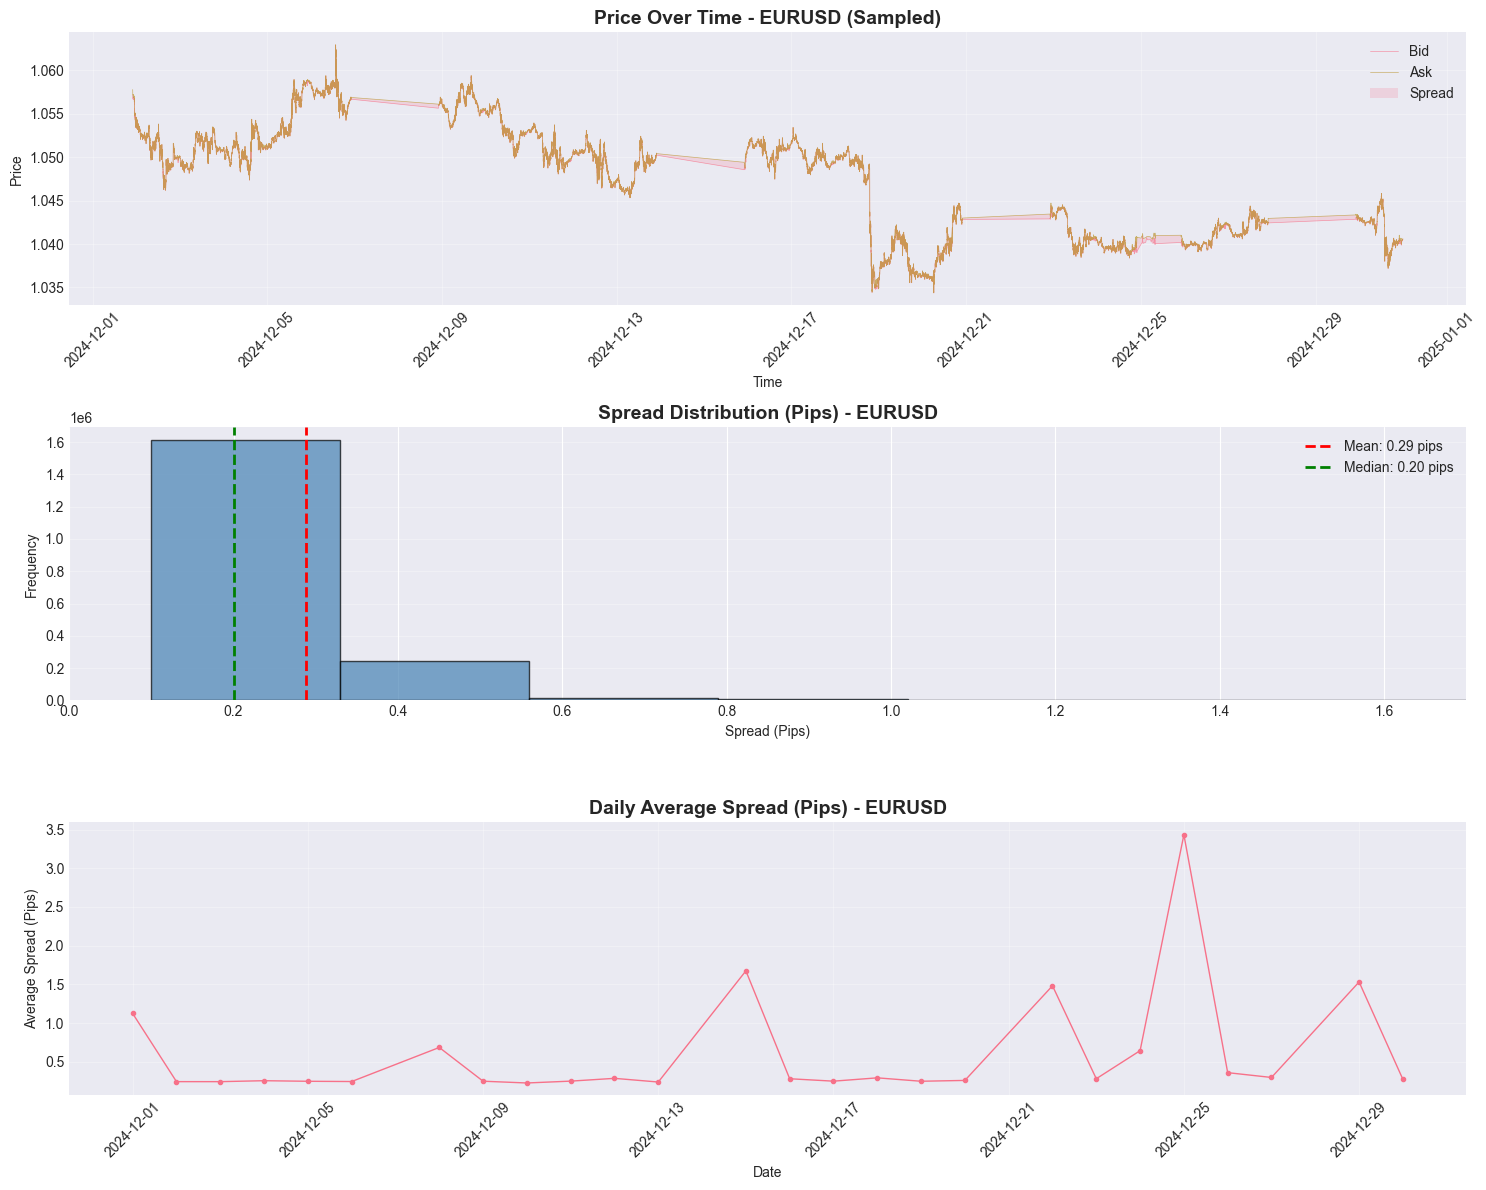

In [10]:
# Visualize price data
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Sample data for visualization (every Nth tick to avoid memory issues)
sample_size = min(50000, len(df))
sample_df = df.iloc[::max(1, len(df)//sample_size)]

# Price over time
axes[0].plot(sample_df['timestamp'], sample_df['bid'], label='Bid', alpha=0.7, linewidth=0.5)
axes[0].plot(sample_df['timestamp'], sample_df['ask'], label='Ask', alpha=0.7, linewidth=0.5)
axes[0].fill_between(sample_df['timestamp'], sample_df['bid'], sample_df['ask'], alpha=0.2, label='Spread')
axes[0].set_title(f'Price Over Time - {SYMBOL} (Sampled)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Price')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Spread distribution
axes[1].hist(df['spread_pips'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].axvline(df['spread_pips'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["spread_pips"].mean():.2f} pips')
axes[1].axvline(df['spread_pips'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["spread_pips"].median():.2f} pips')
axes[1].set_title(f'Spread Distribution (Pips) - {SYMBOL}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Spread (Pips)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xlim(0, min(df['spread_pips'].quantile(0.99), 5))  # Focus on 99th percentile

# Spread over time (daily average)
daily_spread = df.groupby('date')['spread_pips'].mean()
axes[2].plot(daily_spread.index, daily_spread.values, marker='o', markersize=3, linewidth=1)
axes[2].set_title(f'Daily Average Spread (Pips) - {SYMBOL}', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Average Spread (Pips)')
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Temporal Analysis - Time Gaps

In [11]:
# Calculate time differences between consecutive ticks
df['time_diff'] = df['timestamp'].diff()
df['time_diff_seconds'] = df['time_diff'].dt.total_seconds()

print(f"\n{'='*80}")
print("TEMPORAL ANALYSIS")
print(f"{'='*80}")
print(f"\nTime Between Ticks:")
print(df['time_diff_seconds'].describe())

# Identify large gaps
large_gaps = df[df['time_diff'] > timedelta(minutes=5)]
print(f"\nLarge Gaps (>5 minutes): {len(large_gaps):,}")
if len(large_gaps) > 0:
    print(f"\nLargest gaps:")
    top_gaps = large_gaps.nlargest(10, 'time_diff')[['timestamp', 'time_diff']]
    for idx, row in top_gaps.iterrows():
        print(f"  {row['timestamp']}: {row['time_diff']}")

# Check for weekend gaps (expected)
weekend_gaps = large_gaps[large_gaps['timestamp'].dt.dayofweek >= 5]
weekday_gaps = large_gaps[large_gaps['timestamp'].dt.dayofweek < 5]

print(f"\nGap Analysis:")
print(f"  Weekend gaps: {len(weekend_gaps):,} (expected)")
print(f"  Weekday gaps: {len(weekday_gaps):,} (may indicate data issues)")

# Tick frequency analysis
print(f"\nTick Frequency:")
print(f"  Average ticks per second: {1/df['time_diff_seconds'].median():.2f}")
print(f"  Average ticks per minute: {60/df['time_diff_seconds'].median():.2f}")
print(f"  Average ticks per hour: {3600/df['time_diff_seconds'].median():.2f}")


TEMPORAL ANALYSIS

Time Between Ticks:
count    1.902851e+06
mean     1.320519e+00
std      2.532464e+02
min      4.800000e-02
25%      1.050000e-01
50%      1.580000e-01
75%      7.660000e-01
max      1.728110e+05
Name: time_diff_seconds, dtype: float64

Large Gaps (>5 minutes): 34

Largest gaps:
  2024-12-15 22:00:10.088000+00:00: 2 days 00:00:10.972000
  2024-12-29 22:00:08.270000+00:00: 2 days 00:00:09.110000
  2024-12-22 22:00:05.290000+00:00: 2 days 00:00:07.815000
  2024-12-08 22:00:04.394000+00:00: 2 days 00:00:05.153000
  2024-12-25 22:04:01.571000+00:00: 0 days 14:04:01.811000
  2024-12-25 02:33:11.608000+00:00: 0 days 00:18:21.757000
  2024-12-25 05:00:14.617000+00:00: 0 days 00:16:30.201000
  2024-12-25 03:28:12.047000+00:00: 0 days 00:16:21.818000
  2024-12-24 23:29:39.212000+00:00: 0 days 00:14:36.204000
  2024-12-24 23:47:29.728000+00:00: 0 days 00:13:32.660000

Gap Analysis:
  Weekend gaps: 4 (expected)
  Weekday gaps: 30 (may indicate data issues)

Tick Frequency:
  A

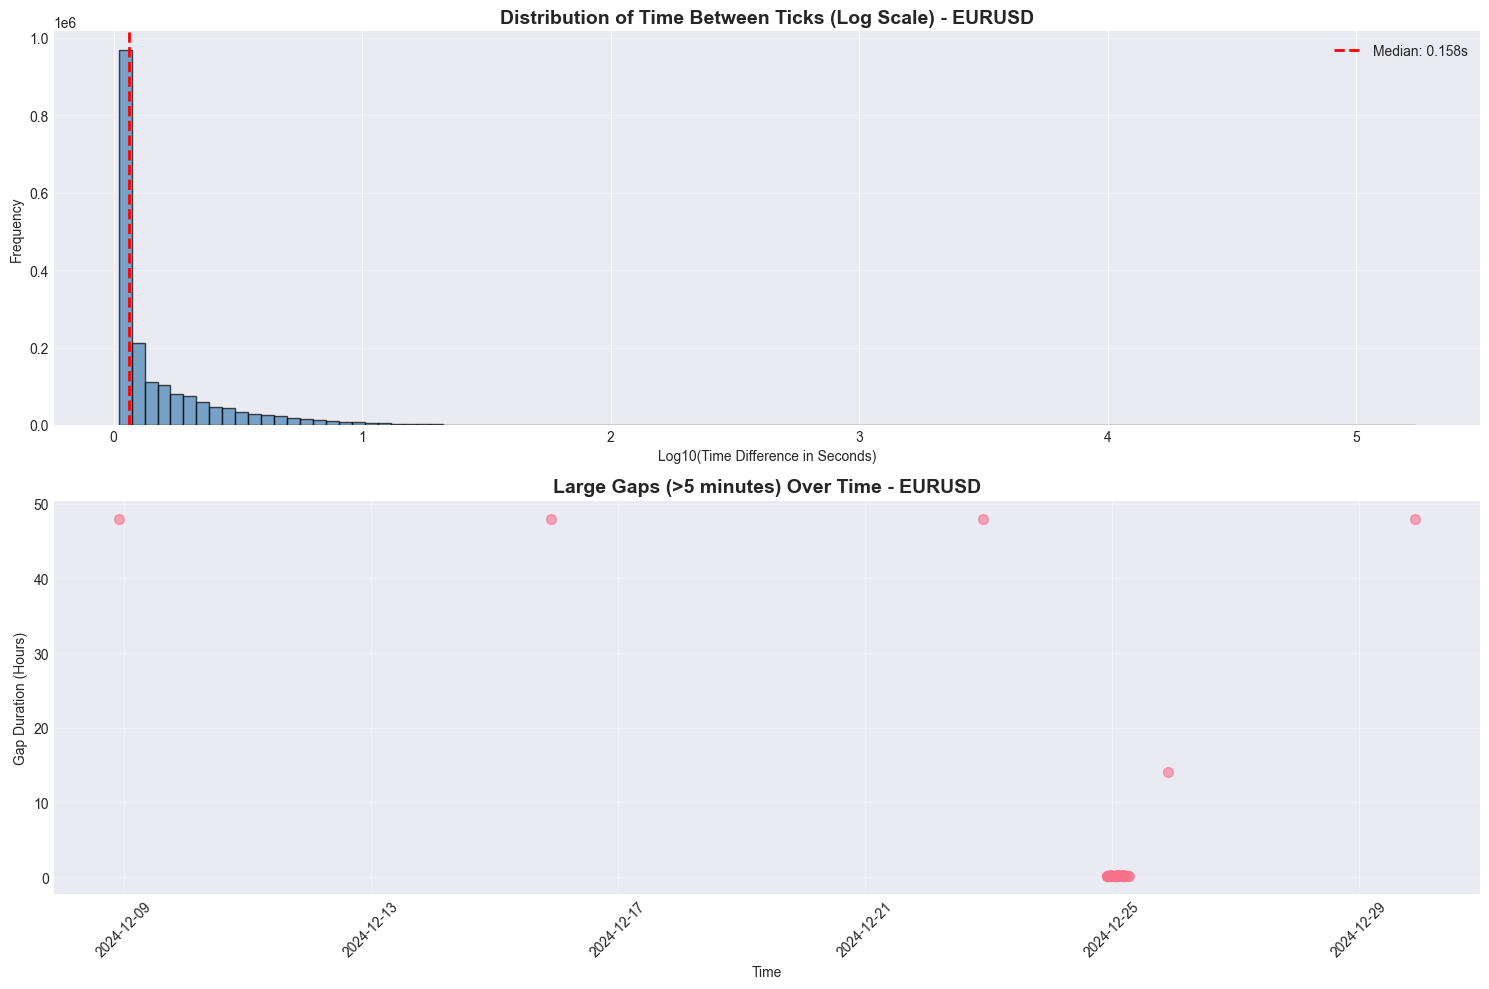

In [12]:
# Visualize time gaps
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Distribution of time differences (log scale)
time_diffs_clean = df['time_diff_seconds'].dropna()
time_diffs_clean = time_diffs_clean[time_diffs_clean > 0]  # Remove negative/zero

axes[0].hist(np.log10(time_diffs_clean + 1), bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.log10(time_diffs_clean.median() + 1), color='red', linestyle='--', linewidth=2, 
                label=f'Median: {time_diffs_clean.median():.3f}s')
axes[0].set_title(f'Distribution of Time Between Ticks (Log Scale) - {SYMBOL}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Log10(Time Difference in Seconds)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Large gaps over time
if len(large_gaps) > 0:
    gap_durations = large_gaps['time_diff'].dt.total_seconds() / 3600  # Convert to hours
    axes[1].scatter(large_gaps['timestamp'], gap_durations, alpha=0.6, s=50)
    axes[1].set_title(f'Large Gaps (>5 minutes) Over Time - {SYMBOL}', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Gap Duration (Hours)')
    axes[1].grid(True, alpha=0.3)
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No large gaps detected', ha='center', va='center', 
                transform=axes[1].transAxes, fontsize=14)
    axes[1].set_title(f'Large Gaps Analysis - {SYMBOL}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Statistical Analysis

In [13]:
# Price changes
df['price_change'] = df['mid_price'].diff()
df['price_change_pct'] = df['price_change'] / df['mid_price'].shift(1) * 100

print(f"\n{'='*80}")
print("PRICE CHANGE STATISTICS")
print(f"{'='*80}")
print(f"\nAbsolute Price Change:")
print(df['price_change'].describe())
print(f"\nPercentage Price Change:")
print(df['price_change_pct'].describe())

# Volatility measures
daily_volatility = df.groupby('date')['price_change_pct'].std()
print(f"\nDaily Volatility (std of % changes):")
print(daily_volatility.describe())

# Correlation analysis
print(f"\n{'='*80}")
print("CORRELATION ANALYSIS")
print(f"{'='*80}")
correlation_cols = ['bid', 'ask', 'spread', 'spread_pips', 'time_diff_seconds']
corr_matrix = df[correlation_cols].corr()
print(corr_matrix)


PRICE CHANGE STATISTICS

Absolute Price Change:
count    1.902851e+06
mean    -8.865644e-09
std      1.317786e-05
min     -1.325000e-03
25%     -5.000000e-06
50%      0.000000e+00
75%      5.000000e-06
max      7.750000e-04
Name: price_change, dtype: float64

Percentage Price Change:
count    1.902851e+06
mean    -8.372468e-07
std      1.257872e-03
min     -1.261574e-01
25%     -4.807091e-04
50%      0.000000e+00
75%      4.807276e-04
max      7.320229e-02
Name: price_change_pct, dtype: float64

Daily Volatility (std of % changes):
count    26.000000
mean      0.001614
std       0.001052
min       0.000962
25%       0.001125
50%       0.001255
75%       0.001566
max       0.005994
Name: price_change_pct, dtype: float64

CORRELATION ANALYSIS
                        bid       ask    spread  spread_pips  \
bid                1.000000  0.999977 -0.086352    -0.086352   
ask                0.999977  1.000000 -0.079581    -0.079581   
spread            -0.086352 -0.079581  1.000000     1.00

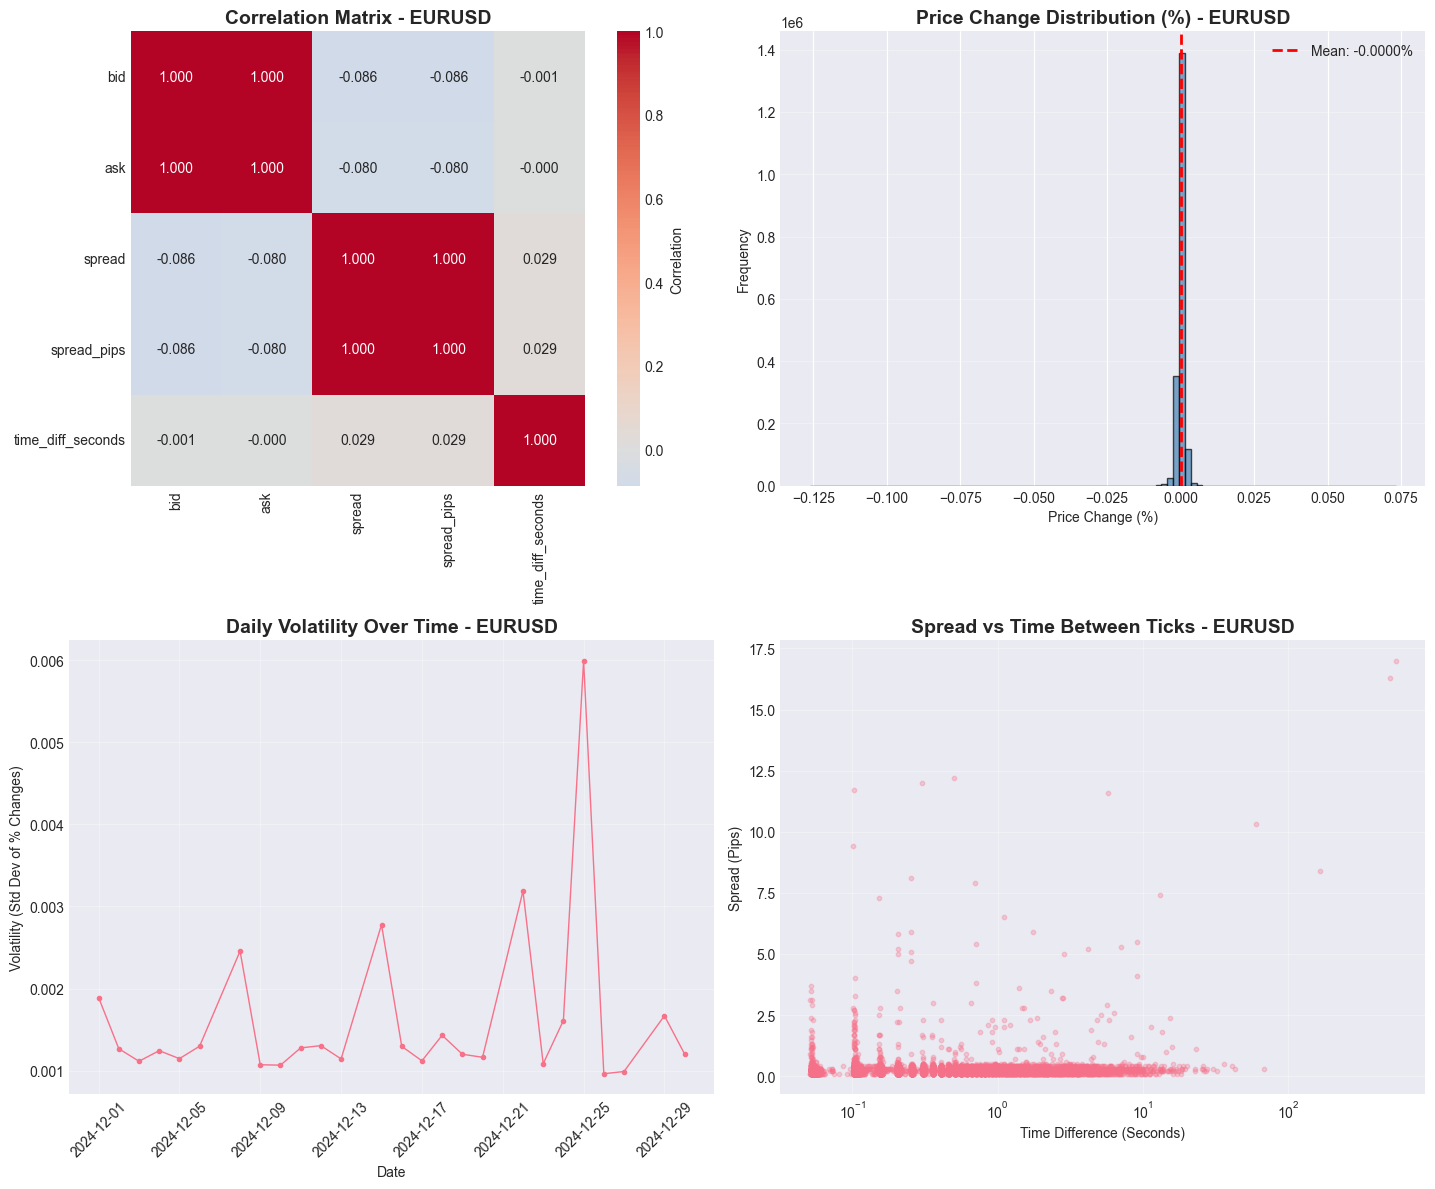

In [14]:
# Visualize correlations and distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Correlation heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, ax=axes[0, 0], cbar_kws={'label': 'Correlation'})
axes[0, 0].set_title(f'Correlation Matrix - {SYMBOL}', fontsize=14, fontweight='bold')

# Price change distribution
price_changes_clean = df['price_change_pct'].dropna()
price_changes_clean = price_changes_clean[(price_changes_clean > -1) & (price_changes_clean < 1)]  # Remove extreme outliers
axes[0, 1].hist(price_changes_clean, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(price_changes_clean.mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {price_changes_clean.mean():.4f}%')
axes[0, 1].set_title(f'Price Change Distribution (%) - {SYMBOL}', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Price Change (%)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Daily volatility
axes[1, 0].plot(daily_volatility.index, daily_volatility.values, marker='o', markersize=3, linewidth=1)
axes[1, 0].set_title(f'Daily Volatility Over Time - {SYMBOL}', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Volatility (Std Dev of % Changes)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Spread vs Time difference
sample_for_scatter = df.sample(min(10000, len(df)))
axes[1, 1].scatter(sample_for_scatter['time_diff_seconds'], sample_for_scatter['spread_pips'], 
                   alpha=0.3, s=10)
axes[1, 1].set_title(f'Spread vs Time Between Ticks - {SYMBOL}', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time Difference (Seconds)')
axes[1, 1].set_ylabel('Spread (Pips)')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Data Quality Summary Report

In [15]:
print(f"\n{'='*80}")
print("DATA QUALITY SUMMARY REPORT")
print(f"{'='*80}")
print(f"\nFile: {PARQUET_FILE}")
print(f"Symbol: {SYMBOL}")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print(f"\n{'─'*80}")
print("1. DATA COMPLETENESS")
print(f"   ✓ Total Records: {len(df):,}")
print(f"   ✓ Date Range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"   ✓ Missing Dates: {len(missing_dates)}")
print(f"   ✓ Null Values: {null_counts.sum()}")
print(f"   ✓ Duplicate Records: {duplicate_count:,}")

print(f"\n{'─'*80}")
print("2. PRICE DATA QUALITY")
print(f"   ✓ Negative Spreads: {negative_spreads:,}")
print(f"   ✓ Zero Spreads: {zero_spreads:,}")
print(f"   ✓ Very Large Spreads (>10 pips): {very_large_spreads:,}")
print(f"   ✓ Mean Spread: {df['spread_pips'].mean():.2f} pips")
print(f"   ✓ Median Spread: {df['spread_pips'].median():.2f} pips")

print(f"\n{'─'*80}")
print("3. TEMPORAL QUALITY")
print(f"   ✓ Large Gaps (>5 min): {len(large_gaps):,}")
print(f"   ✓ Weekday Gaps: {len(weekday_gaps):,}")
print(f"   ✓ Average Ticks/Hour: {3600/df['time_diff_seconds'].median():.0f}")

print(f"\n{'─'*80}")
print("4. STATISTICAL METRICS")
print(f"   ✓ Price Range: {df['bid'].min():.5f} - {df['ask'].max():.5f}")
print(f"   ✓ Mean Daily Volatility: {daily_volatility.mean():.4f}%")
print(f"   ✓ Price Change Outliers: {((df['price_change_pct'].abs() > 1).sum()):,}")

# Overall quality score
quality_score = 100
issues = []

if null_counts.sum() > 0:
    quality_score -= 10
    issues.append("Null values present")
if duplicate_count > len(df) * 0.01:
    quality_score -= 5
    issues.append("High duplicate rate")
if negative_spreads > 0:
    quality_score -= 20
    issues.append("Negative spreads")
if len(weekday_gaps) > 10:
    quality_score -= 10
    issues.append("Many weekday gaps")
if len(missing_dates) > len(date_range) * 0.05:
    quality_score -= 15
    issues.append("Many missing dates")

quality_score = max(0, quality_score)

print(f"\n{'─'*80}")
print("OVERALL QUALITY SCORE")
print(f"   Score: {quality_score}/100")
if issues:
    print(f"   Issues: {', '.join(issues)}")
else:
    print(f"   ✓ No major issues detected")

if quality_score >= 90:
    print(f"   Status: ✓ EXCELLENT")
elif quality_score >= 75:
    print(f"   Status: ✓ GOOD")
elif quality_score >= 60:
    print(f"   Status: ⚠️  ACCEPTABLE")
else:
    print(f"   Status: ⚠️  NEEDS ATTENTION")

print(f"\n{'='*80}")


DATA QUALITY SUMMARY REPORT

File: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2024.parquet
Symbol: EURUSD
Analysis Date: 2026-01-18 18:06:22

────────────────────────────────────────────────────────────────────────────────
1. DATA COMPLETENESS
   ✓ Total Records: 1,902,852
   ✓ Date Range: 2024-12-01 to 2024-12-30
   ✓ Missing Dates: 4
   ✓ Null Values: 0
   ✓ Duplicate Records: 0

────────────────────────────────────────────────────────────────────────────────
2. PRICE DATA QUALITY
   ✓ Negative Spreads: 0
   ✓ Zero Spreads: 0
   ✓ Very Large Spreads (>10 pips): 484
   ✓ Mean Spread: 0.29 pips
   ✓ Median Spread: 0.20 pips

────────────────────────────────────────────────────────────────────────────────
3. TEMPORAL QUALITY
   ✓ Large Gaps (>5 min): 34
   ✓ Weekday Gaps: 30
   ✓ Average Ticks/Hour: 22785

────────────────────────────────────────────────────────────────────────────────
4. STATISTICAL METRICS
   ✓ Price Range: 1.03429 - 1.06300
   ✓ Mean Daily Volatility: 0

In [6]:
from pathlib import Path
from analyze_dukascopy_data_quality import DataQualityAnalyzer

# Helper: detect project root (same logic as earlier cell)
current = Path.cwd()
if (current / "data").exists():
    PROJECT_ROOT = current
elif (current.parent / "data").exists():
    PROJECT_ROOT = current.parent
else:
    PROJECT_ROOT = current.parent

symbol = "EURUSD"
parquet_files = [
    PROJECT_ROOT / "data" / "dukascopy" / symbol / "2024.parquet",
    PROJECT_ROOT / "data" / "dukascopy" / symbol / "2025.parquet",
]

print(f"Project root: {PROJECT_ROOT}")
print("Files to analyze:")
for f in parquet_files:
    print(" -", f, "exists=", f.exists())

results_by_year = {}

for f in parquet_files:
    year = f.stem  # '2024', '2025', etc.
    print(f"\n=== Running quality analysis for {symbol} {year} ===")
    analyzer = DataQualityAnalyzer(f, symbol, output_dir=f.parent)
    analyzer.load_data()
    report = analyzer.generate_report()
    analyzer.print_summary()
    results_by_year[year] = report

# Optional: load both years together to inspect 2-year coverage
import pandas as pd

existing_files = [f for f in parquet_files if f.exists()]
if existing_files:
    print("\n=== Combined 2-year dataset summary ===")
    df_all = pd.concat([pd.read_parquet(f) for f in existing_files], ignore_index=True)
    df_all["timestamp"] = pd.to_datetime(df_all["timestamp"], utc=True)
    df_all = df_all.sort_values("timestamp")
    print("Total records:", len(df_all))
    print("Date range:", df_all["timestamp"].min(), "->", df_all["timestamp"].max())
    print("Rows per year:")
    print(df_all.groupby(df_all["timestamp"].dt.year).size())
else:
    print("No parquet files found to build combined dataset.")

2026-01-20 08:33:39,501 - INFO - Loading data from: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2024.parquet


Project root: c:\Users\maxno\Desktop\Projet\1.1
Files to analyze:
 - c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2024.parquet exists= True
 - c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2025.parquet exists= True

=== Running quality analysis for EURUSD 2024 ===


2026-01-20 08:33:40,941 - INFO - Loaded 20,687,149 records
2026-01-20 08:33:41,035 - INFO - Date range: 2024-01-01 22:00:12.108000+00:00 to 2024-12-31 21:59:58.249000+00:00
2026-01-20 08:33:41,035 - INFO - Generating analysis report...
2026-01-20 08:33:41,036 - INFO - Analyzing basic information...
2026-01-20 08:33:41,280 - INFO - Analyzing data completeness...
2026-01-20 08:33:58,314 - INFO - Analyzing price data...
2026-01-20 08:34:01,946 - INFO - Analyzing temporal patterns...
2026-01-20 08:34:05,453 - INFO - Performing statistical analysis...
2026-01-20 08:34:09,800 - INFO - Calculating quality score...
2026-01-20 08:34:09,801 - INFO - Creating visualizations...
2026-01-20 08:34:16,796 - INFO - Visualizations saved to: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\quality_analysis



DATA QUALITY ANALYSIS SUMMARY

File: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2024.parquet
Symbol: EURUSD
Total Records: 20,687,149
Date Range: 2024-01-01T22:00:12.108000+00:00 to 2024-12-31T21:59:58.249000+00:00

--------------------------------------------------------------------------------
QUALITY SCORE
--------------------------------------------------------------------------------
Score: 75/100
Status: GOOD
Issues: Many missing dates (14.2%)
Warnings: Many weekday gaps

--------------------------------------------------------------------------------
KEY METRICS
--------------------------------------------------------------------------------
Mean Spread: 0.26 pips
Negative Spreads: 0
Weekday Gaps: 43
Missing Days: 52
Average Ticks/Hour: 17391


=== Running quality analysis for EURUSD 2025 ===


2026-01-20 08:34:17,049 - INFO - Loading data from: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2025.parquet
2026-01-20 08:34:18,685 - INFO - Loaded 23,460,873 records
2026-01-20 08:34:18,786 - INFO - Date range: 2025-01-01 22:00:14.647000+00:00 to 2025-12-31 21:58:59.891000+00:00
2026-01-20 08:34:18,786 - INFO - Generating analysis report...
2026-01-20 08:34:18,787 - INFO - Analyzing basic information...
2026-01-20 08:34:19,043 - INFO - Analyzing data completeness...
2026-01-20 08:34:38,467 - INFO - Analyzing price data...
2026-01-20 08:34:42,629 - INFO - Analyzing temporal patterns...
2026-01-20 08:34:46,618 - INFO - Performing statistical analysis...
2026-01-20 08:34:51,415 - INFO - Calculating quality score...
2026-01-20 08:34:51,417 - INFO - Creating visualizations...
2026-01-20 08:34:59,038 - INFO - Visualizations saved to: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\quality_analysis



DATA QUALITY ANALYSIS SUMMARY

File: c:\Users\maxno\Desktop\Projet\1.1\data\dukascopy\EURUSD\2025.parquet
Symbol: EURUSD
Total Records: 23,460,873
Date Range: 2025-01-01T22:00:14.647000+00:00 to 2025-12-31T21:58:59.891000+00:00

--------------------------------------------------------------------------------
QUALITY SCORE
--------------------------------------------------------------------------------
Score: 75/100
Status: GOOD
Issues: Many missing dates (14.2%)
Warnings: Many weekday gaps

--------------------------------------------------------------------------------
KEY METRICS
--------------------------------------------------------------------------------
Mean Spread: 0.50 pips
Negative Spreads: 0
Weekday Gaps: 34
Missing Days: 52
Average Ticks/Hour: 17561


=== Combined 2-year dataset summary ===
Total records: 44148022
Date range: 2024-01-01 22:00:12.108000+00:00 -> 2025-12-31 21:58:59.891000+00:00
Rows per year:
timestamp
2024    20687149
2025    23460873
dtype: int64
